In [1]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
import mlflow
import mlflow.xgboost
from mlflow.tracking import MlflowClient
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

os.environ["LOGNAME"]  = "Yulia"
os.environ["USER"]     = "Yulia"
os.environ["USERNAME"] = "Yulia"

# Поиск корня проекта по маркеру PROJECT_CONTEXT.md
def find_project_root(marker="PROJECT_CONTEXT.md"):
    current = Path.cwd().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Не найден корень проекта (нет файла {marker})")

project_root = find_project_root()
print(f"Корень проекта: {project_root}")

data_path = project_root / "data" / "processed" / "training_set_v1.parquet"
print(f"Путь к данным : {data_path}")
print(f"Файл существует: {data_path.exists()}")

df = pd.read_parquet(data_path)
print(f"\nДатасет загружен: {df.shape}")
print(f"Период: {df['incident_hour'].min()} .. {df['incident_hour'].max()}")

Корень проекта: C:\metro-bus-ml
Путь к данным : C:\metro-bus-ml\data\processed\training_set_v1.parquet
Файл существует: True

Датасет загружен: (1394946, 14)
Период: 2024-10-01 00:00:00 .. 2024-12-31 22:00:00


In [2]:
# Feature engineering — 10 новых колонок
df["hour"]          = df["incident_hour"].dt.hour
df["day_of_week"]   = df["incident_hour"].dt.dayofweek
df["is_weekend"]    = (df["day_of_week"] >= 5).astype(int)
df["month"]         = df["incident_hour"].dt.month
df["day_of_month"]  = df["incident_hour"].dt.day

df["time_of_day"] = pd.cut(
    df["hour"],
    bins=[-1, 6, 10, 16, 20, 24],
    labels=["night", "morning_rush", "midday", "evening_rush", "evening"],
)

df["status_main"] = df["status_label"].str.split().str[0].fillna("unknown")
df["is_express"]  = df["bus_route"].str.contains(r"\+$|X$", regex=True, na=False).astype(int)

# Принадлежность маршрута затронутой зоне (route_in_zone)
def route_in_affected_zone(row):
    if pd.isna(row["boroughs_affected_str"]) or pd.isna(row["route_borough"]):
        return 0
    return int(row["route_borough"] in row["boroughs_affected_str"])

df_feat = df.copy()
if "route_borough" not in df_feat.columns:
    borough_map = {"M": "Manhattan", "B": "Brooklyn", "Q": "Queens",
                   "BX": "Bronx", "S": "StatenIsland"}
    df_feat["route_prefix"] = df_feat["bus_route"].str.extract(r"^([A-Z]+)")
    df_feat["route_borough"] = df_feat["route_prefix"].map(borough_map).fillna("Unknown")

df_feat["route_in_zone"] = df_feat.apply(route_in_affected_zone, axis=1)

print(f"df_feat shape: {df_feat.shape}")

# Train/test split по времени
train_mask = (df_feat["incident_hour"] >= "2024-10-01") & (df_feat["incident_hour"] <= "2024-11-17")
test_mask  = (df_feat["incident_hour"] >= "2024-12-01") & (df_feat["incident_hour"] <= "2024-12-22")

train_df = df_feat[train_mask].copy()
test_df  = df_feat[test_mask].copy()

print(f"Train: {len(train_df):,} строк, {train_df['event_id'].nunique()} инцидентов")
print(f"Test : {len(test_df):,} строк, {test_df['event_id'].nunique()} инцидентов")
print(f"Mean target Train: {train_df['uplift_t1'].mean():+.2f}")
print(f"Mean target Test : {test_df['uplift_t1'].mean():+.2f}")

# Подготовка X / y
numeric_features = [
    "hour", "day_of_week", "is_weekend", "month", "day_of_month",
    "num_lines_affected", "n_boroughs_affected", "is_express", "route_in_zone",
    "baseline_t0", "baseline_t1", "actual_t0",
]
categorical_features = ["time_of_day", "status_main", "route_borough"]
target_col = "uplift_t1"

train_df = train_df.dropna(subset=[target_col])
test_df  = test_df.dropna(subset=[target_col])

X_train_num = train_df[numeric_features].copy()
X_test_num  = test_df[numeric_features].copy()

X_train_cat = pd.get_dummies(train_df[categorical_features], drop_first=False)
X_test_cat  = pd.get_dummies(test_df[categorical_features],  drop_first=False)

X_train = pd.concat([X_train_num.reset_index(drop=True),
                     X_train_cat.reset_index(drop=True)], axis=1)
X_test  = pd.concat([X_test_num.reset_index(drop=True),
                     X_test_cat.reset_index(drop=True)],  axis=1)

# Выравнивание колонок test по train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df[target_col].reset_index(drop=True)
y_test  = test_df[target_col].reset_index(drop=True)

print(f"\nX_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"Признаков всего: {X_train.shape[1]}")

df_feat shape: (1394946, 25)
Train: 823,285 строк, 2807 инцидентов
Test : 386,310 строк, 1323 инцидентов
Mean target Train: +7.59
Mean target Test : +2.62

X_train: (823285, 32)
X_test : (386310, 32)
Признаков всего: 32


In [3]:
import os
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb
import mlflow
import mlflow.xgboost
from mlflow.tracking import MlflowClient
from sklearn.metrics import mean_absolute_error, mean_squared_error

os.environ["LOGNAME"]  = "Yulia"
os.environ["USER"]     = "Yulia"
os.environ["USERNAME"] = "Yulia"

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
mlflow.set_tracking_uri(f"file:{(project_root / 'mlruns').as_posix()}")

# Метрики (тот же помощник, что в Day 5-6)
def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = np.abs(y_true) > 1.0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    return mae, rmse, mape, int(mask.sum())


# ============================================================
# 1. Лучшие параметры Optuna (из Day 5)
# ============================================================
best_params = {
    "objective":        "reg:squarederror",
    "tree_method":      "hist",
    "random_state":     42,
    "n_jobs":           -1,
    "n_estimators":     150,
    "max_depth":        11,
    "learning_rate":    0.025394743526288403,
    "subsample":        0.7764516208812864,
    "colsample_bytree": 0.9728932430396474,
    "min_child_weight": 4,
    "reg_lambda":       0.85180641935179,
}


# ============================================================
# 2. Определение temporal-признаков (из Day 6 ablation)
# ============================================================
temporal_features = [
    "hour", "day_of_week", "is_weekend", "month", "day_of_month",
] + [c for c in X_train.columns if c.startswith("time_of_day_")]

print("Temporal-признаки, которые УБИРАЕМ из v2:")
for f in temporal_features:
    print(f"  - {f}")
print(f"\nИтого удаляется: {len(temporal_features)} признаков из {X_train.shape[1]}")


# ============================================================
# 3. Подготовка X_train_v2 / X_test_v2 без temporal
# ============================================================
keep_features = [c for c in X_train.columns if c not in temporal_features]
X_train_v2 = X_train[keep_features].copy()
X_test_v2  = X_test[keep_features].copy()

print(f"\nv1: {X_train.shape[1]} признаков (полный набор)")
print(f"v2: {X_train_v2.shape[1]} признаков (без temporal)")


# ============================================================
# 4. Обучение v1 для финального сравнения (на тех же данных)
# ============================================================
print("\n" + "=" * 60)
print("Обучение v1 (полный набор признаков, для финального сравнения)")
print("=" * 60)

t_start = time.time()
model_v1 = xgb.XGBRegressor(**best_params)
model_v1.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
train_time_v1 = time.time() - t_start

t_start = time.time()
y_pred_v1 = model_v1.predict(X_test)
inference_time_v1 = time.time() - t_start

mae_v1, rmse_v1, mape_v1, _ = calc_metrics(y_test.values, y_pred_v1)
print(f"v1 MAE  = {mae_v1:.4f}")
print(f"v1 RMSE = {rmse_v1:.4f}")
print(f"v1 время обучения  = {train_time_v1:.1f} сек")
print(f"v1 время инференса = {inference_time_v1*1000:.0f} мс")


# ============================================================
# 5. Обучение v2 (без temporal)
# ============================================================
print("\n" + "=" * 60)
print("Обучение v2 (без temporal-признаков)")
print("=" * 60)

t_start = time.time()
model_v2 = xgb.XGBRegressor(**best_params)
model_v2.fit(X_train_v2, y_train, eval_set=[(X_test_v2, y_test)], verbose=False)
train_time_v2 = time.time() - t_start

t_start = time.time()
y_pred_v2 = model_v2.predict(X_test_v2)
inference_time_v2 = time.time() - t_start

mae_v2, rmse_v2, mape_v2, _ = calc_metrics(y_test.values, y_pred_v2)
print(f"v2 MAE  = {mae_v2:.4f}")
print(f"v2 RMSE = {rmse_v2:.4f}")
print(f"v2 время обучения  = {train_time_v2:.1f} сек")
print(f"v2 время инференса = {inference_time_v2*1000:.0f} мс")


# ============================================================
# 6. Сравнительная таблица v1 vs v2
# ============================================================
print("\n" + "=" * 80)
print("СРАВНЕНИЕ v1 vs v2 — раздел 4.4 ВКР")
print("=" * 80)

comparison = pd.DataFrame([
    {
        "Версия":            "v1",
        "Признаков":         X_train.shape[1],
        "Без temporal":      "нет",
        "MAE":               round(mae_v1, 4),
        "RMSE":              round(rmse_v1, 4),
        "Время обуч., сек":  round(train_time_v1, 1),
        "Время инф., мс":    round(inference_time_v1 * 1000, 1),
    },
    {
        "Версия":            "v2",
        "Признаков":         X_train_v2.shape[1],
        "Без temporal":      "да",
        "MAE":               round(mae_v2, 4),
        "RMSE":              round(rmse_v2, 4),
        "Время обуч., сек":  round(train_time_v2, 1),
        "Время инф., мс":    round(inference_time_v2 * 1000, 1),
    },
])
print(comparison.to_string(index=False))

mae_improvement  = (mae_v1 - mae_v2) / mae_v1 * 100
rmse_improvement = (rmse_v1 - rmse_v2) / rmse_v1 * 100
print(f"\nУлучшение MAE  v1 → v2: {mae_improvement:+.2f}%")
print(f"Улучшение RMSE v1 → v2: {rmse_improvement:+.2f}%")
print("=" * 80)


# ============================================================
# 7. Логирование v2 в новый эксперимент
# ============================================================
mlflow.set_experiment("metro_bus_uplift_v4_production")

with mlflow.start_run(run_name="xgboost_v2_no_temporal_PRODUCTION"):
    mlflow.log_params({
        "model_type":      "xgboost",
        "model_version":   "v2",
        "tuning":          "optuna_30_trials",
        "removed_group":   "temporal",
        "n_features":      X_train_v2.shape[1],
        "n_train":         len(y_train),
        "n_test":          len(y_test),
        "train_period":    "2024-10-01 .. 2024-11-17",
        "test_period":     "2024-12-01 .. 2024-12-22",
        **{f"hp_{k}": v for k, v in best_params.items()},
    })
    mlflow.log_metrics({
        "mae":               mae_v2,
        "rmse":              rmse_v2,
        "mape":              mape_v2 if not np.isnan(mape_v2) else -1.0,
        "train_time_sec":    train_time_v2,
        "inference_time_ms": inference_time_v2 * 1000,
        "mae_improvement_vs_v1_pct":  mae_improvement,
        "rmse_improvement_vs_v1_pct": rmse_improvement,
    })
    mlflow.xgboost.log_model(model_v2, artifact_path="model")

print("\nv2 залогирована в эксперимент metro_bus_uplift_v4_production")


# ============================================================
# 8. Экспорт v2 в models/ для использования в API
# ============================================================
models_dir = project_root / "models"

model_v2_path = models_dir / "xgboost_v2.json"
model_v2.save_model(str(model_v2_path))
print(f"\nv2 сохранена: {model_v2_path}")
print(f"Размер файла: {model_v2_path.stat().st_size / 1024:.1f} КБ")

# Метаданные v2
metadata_v2 = {
    "model_version":   "v2",
    "model_type":      "xgboost",
    "tuning":          "optuna_30_trials",
    "removed_group":   "temporal",
    "metrics_on_test": {
        "mae":  mae_v2,
        "rmse": rmse_v2,
        "mape": mape_v2,
    },
    "improvement_vs_v1": {
        "mae_pct":  mae_improvement,
        "rmse_pct": rmse_improvement,
    },
    "hyperparameters": {k: v for k, v in best_params.items()},
    "training_data": {
        "n_train":      len(y_train),
        "n_test":       len(y_test),
        "n_features":   X_train_v2.shape[1],
        "train_period": "2024-10-01 .. 2024-11-17",
        "test_period":  "2024-12-01 .. 2024-12-22",
    },
    "feature_names": list(X_train_v2.columns),
}

metadata_v2_path = models_dir / "xgboost_v2_metadata.json"
with open(metadata_v2_path, "w", encoding="utf-8") as f:
    json.dump(metadata_v2, f, indent=2, ensure_ascii=False)
print(f"Метаданные v2: {metadata_v2_path}")

# Список фичей v2 — отдельным файлом для API
features_v2_path = models_dir / "feature_columns_v2.json"
with open(features_v2_path, "w", encoding="utf-8") as f:
    json.dump(list(X_train_v2.columns), f, indent=2, ensure_ascii=False)
print(f"Список фичей v2: {features_v2_path}")
print(f"Признаков в v2: {X_train_v2.shape[1]}")

Temporal-признаки, которые УБИРАЕМ из v2:
  - hour
  - day_of_week
  - is_weekend
  - month
  - day_of_month
  - time_of_day_night
  - time_of_day_morning_rush
  - time_of_day_midday
  - time_of_day_evening_rush
  - time_of_day_evening

Итого удаляется: 10 признаков из 32

v1: 32 признаков (полный набор)
v2: 22 признаков (без temporal)

Обучение v1 (полный набор признаков, для финального сравнения)
v1 MAE  = 10.7489
v1 RMSE = 23.1835
v1 время обучения  = 23.0 сек
v1 время инференса = 634 мс

Обучение v2 (без temporal-признаков)


2026/04/29 14:15:30 INFO mlflow.tracking.fluent: Experiment with name 'metro_bus_uplift_v4_production' does not exist. Creating a new experiment.


v2 MAE  = 10.5900
v2 RMSE = 22.7150
v2 время обучения  = 17.7 сек
v2 время инференса = 610 мс

СРАВНЕНИЕ v1 vs v2 — раздел 4.4 ВКР
Версия  Признаков Без temporal     MAE    RMSE  Время обуч., сек  Время инф., мс
    v1         32          нет 10.7489 23.1835              23.0           633.9
    v2         22           да 10.5900 22.7150              17.7           610.4

Улучшение MAE  v1 → v2: +1.48%
Улучшение RMSE v1 → v2: +2.02%


c:\metro-bus-ml\.venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:15:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
2026/04/29 14:15:43 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



v2 залогирована в эксперимент metro_bus_uplift_v4_production

v2 сохранена: c:\metro-bus-ml\models\xgboost_v2.json
Размер файла: 12585.9 КБ
Метаданные v2: c:\metro-bus-ml\models\xgboost_v2_metadata.json
Список фичей v2: c:\metro-bus-ml\models\feature_columns_v2.json
Признаков в v2: 22


Случаев, где v2 точнее v1: 195,534 (50.6%)
Случаев, где v1 точнее v2: 190,776 (49.4%)
Одинаково:                  0

Среднее улучшение на тех примерах, где v2 лучше: 2.881
Среднее ухудшение на тех примерах, где v1 лучше:  2.632


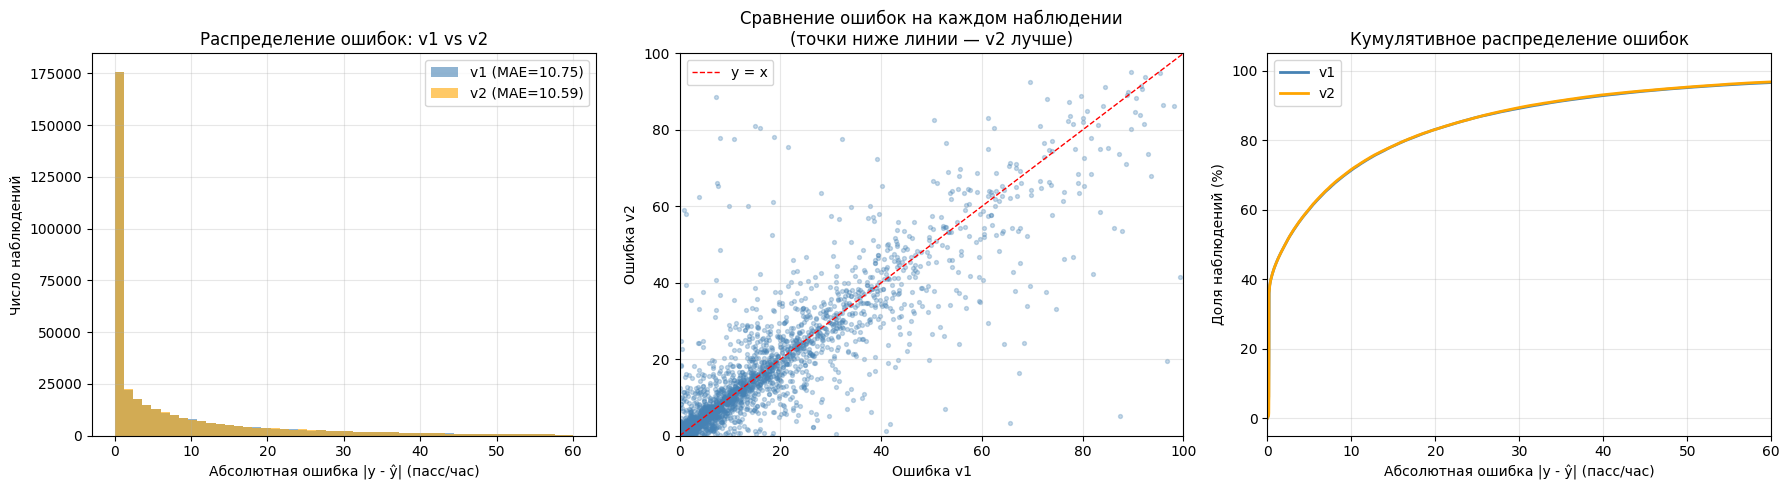


График сохранён: c:\metro-bus-ml\reports\v1_vs_v2_error_analysis.png


In [4]:
import matplotlib.pyplot as plt

# Считаем абсолютные ошибки на test
errors_v1 = np.abs(y_test.values - y_pred_v1)
errors_v2 = np.abs(y_test.values - y_pred_v2)

# Diff: насколько v2 точнее v1 на каждом примере
diff = errors_v1 - errors_v2  # положительное значение = v2 лучше

print(f"Случаев, где v2 точнее v1: {(diff > 0).sum():,} ({(diff > 0).mean()*100:.1f}%)")
print(f"Случаев, где v1 точнее v2: {(diff < 0).sum():,} ({(diff < 0).mean()*100:.1f}%)")
print(f"Одинаково:                  {(diff == 0).sum():,}")
print(f"\nСреднее улучшение на тех примерах, где v2 лучше: {diff[diff > 0].mean():.3f}")
print(f"Среднее ухудшение на тех примерах, где v1 лучше:  {-diff[diff < 0].mean():.3f}")

# ============================================================
# Графики для раздела 4.4 ВКР
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: распределение абсолютных ошибок
axes[0].hist(errors_v1, bins=50, alpha=0.6, label=f"v1 (MAE={mae_v1:.2f})", color="steelblue", range=(0, 60))
axes[0].hist(errors_v2, bins=50, alpha=0.6, label=f"v2 (MAE={mae_v2:.2f})", color="orange", range=(0, 60))
axes[0].set_xlabel("Абсолютная ошибка |y - ŷ| (пасс/час)")
axes[0].set_ylabel("Число наблюдений")
axes[0].set_title("Распределение ошибок: v1 vs v2")
axes[0].legend()
axes[0].grid(alpha=0.3)

# График 2: scatter v1 vs v2 ошибок
sample_idx = np.random.choice(len(errors_v1), size=5000, replace=False)
axes[1].scatter(errors_v1[sample_idx], errors_v2[sample_idx], alpha=0.3, s=8, color="steelblue")
max_err = max(errors_v1[sample_idx].max(), errors_v2[sample_idx].max())
axes[1].plot([0, max_err], [0, max_err], "r--", linewidth=1, label="y = x")
axes[1].set_xlabel("Ошибка v1")
axes[1].set_ylabel("Ошибка v2")
axes[1].set_title("Сравнение ошибок на каждом наблюдении\n(точки ниже линии — v2 лучше)")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)

# График 3: cumulative distribution
sorted_v1 = np.sort(errors_v1)
sorted_v2 = np.sort(errors_v2)
cum_pct = np.arange(1, len(sorted_v1) + 1) / len(sorted_v1) * 100

axes[2].plot(sorted_v1, cum_pct, label=f"v1", color="steelblue", linewidth=2)
axes[2].plot(sorted_v2, cum_pct, label=f"v2", color="orange", linewidth=2)
axes[2].set_xlabel("Абсолютная ошибка |y - ŷ| (пасс/час)")
axes[2].set_ylabel("Доля наблюдений (%)")
axes[2].set_title("Кумулятивное распределение ошибок")
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[2].set_xlim(0, 60)

plt.tight_layout()

fig_path = project_root / "reports" / "v1_vs_v2_error_analysis.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nГрафик сохранён: {fig_path}")